<a href="https://colab.research.google.com/github/tien10022001/txldl/blob/main/Asm1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== THỐNG KÊ ===
            price       area  bedrooms
count    6.000000   7.000000  7.000000
mean   141.666667  52.857143  2.428571
std    120.069424  29.840848  1.272418
min    -50.000000 -10.000000  0.000000
25%    100.000000  50.000000  2.000000
50%    150.000000  60.000000  3.000000
75%    200.000000  70.000000  3.000000
max    300.000000  80.000000  4.000000

Median:
 price       150.0
area         60.0
bedrooms      3.0
dtype: float64

Missing values:
 price          1
area           0
bedrooms       0
condition      1
location       1
description    1
dtype: int64

Duplicate: 1


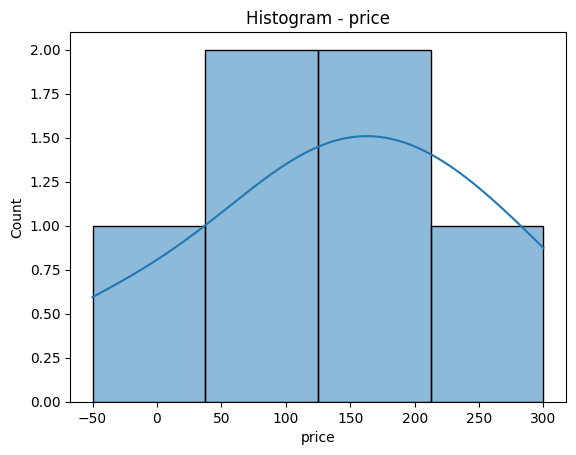

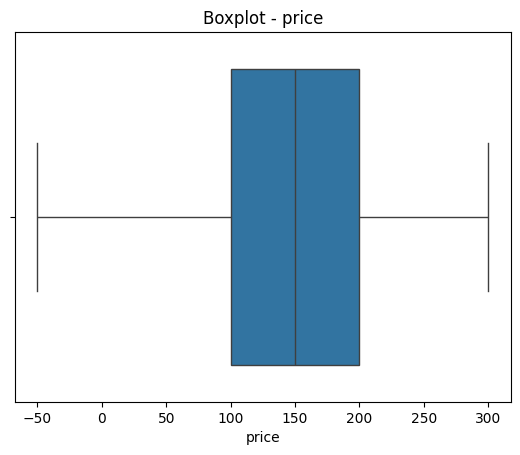

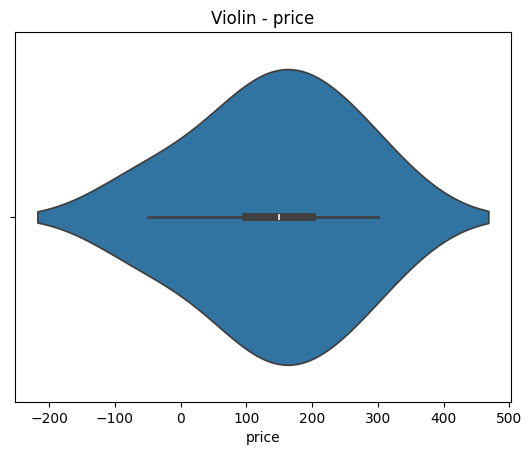

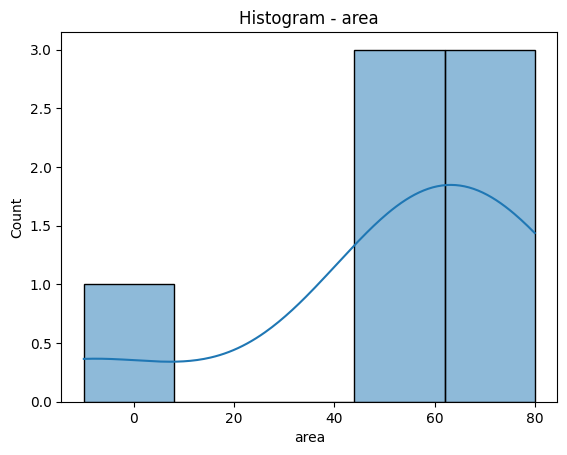

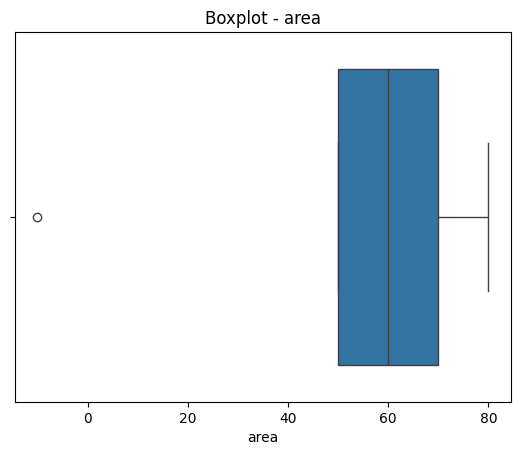

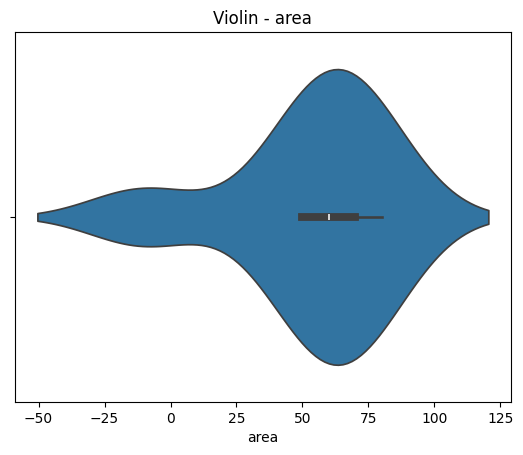

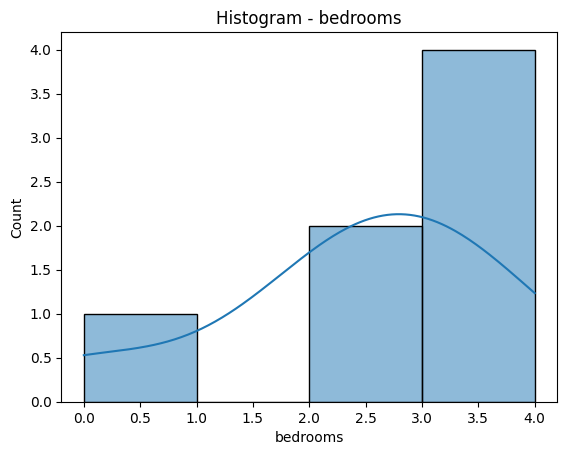

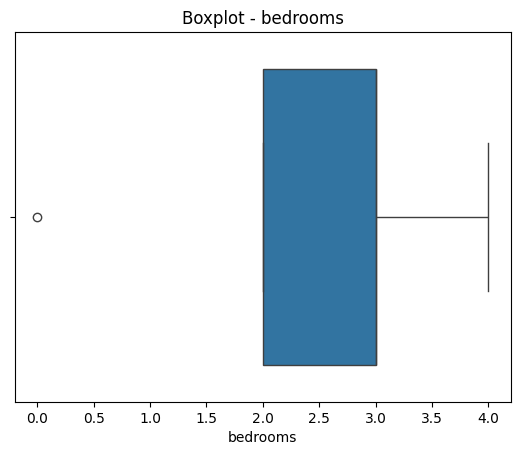

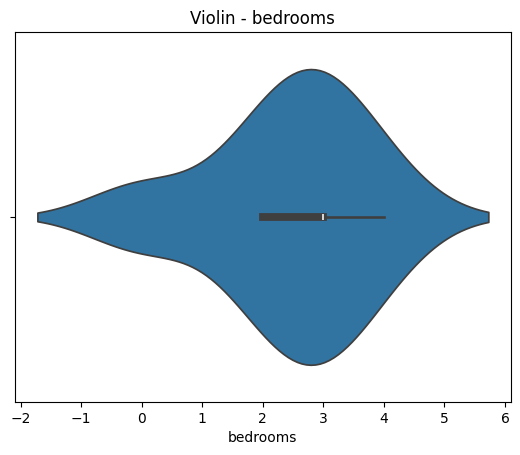


condition:
 condition
new     2
old     2
nwe     1
new     1
Name: count, dtype: int64


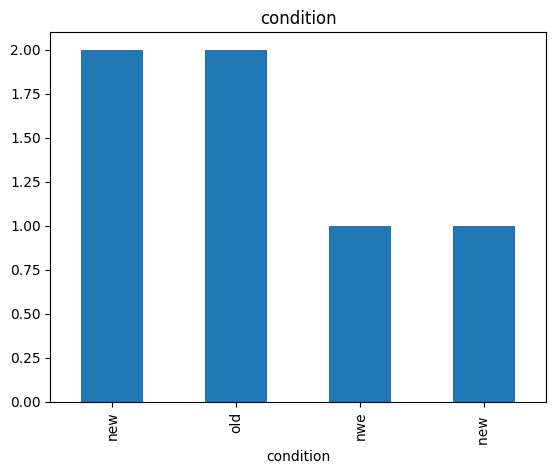


location:
 location
HN     4
HCM    2
Name: count, dtype: int64


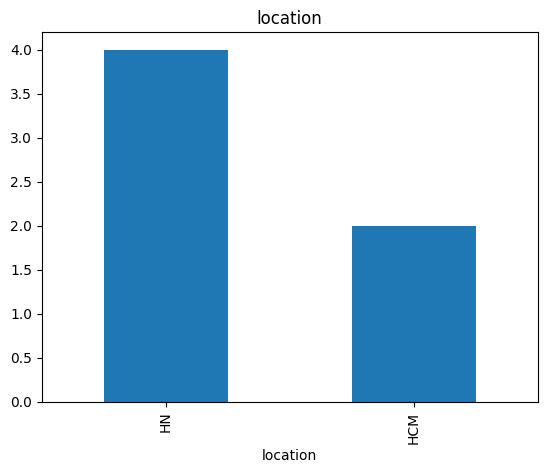


description:
 description
dep              3
gan trung tam    1
view dep         1
re               1
Name: count, dtype: int64


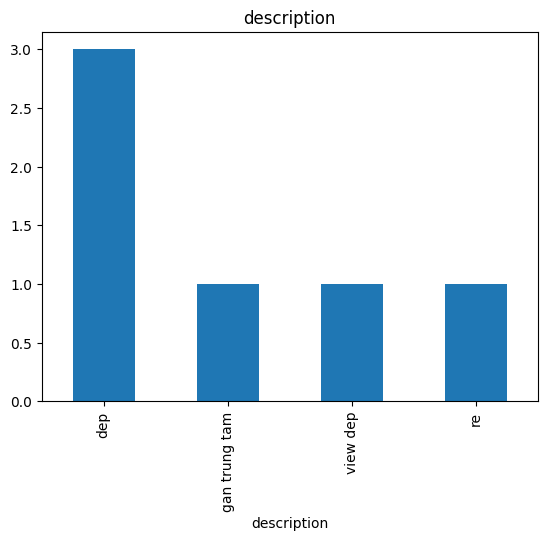

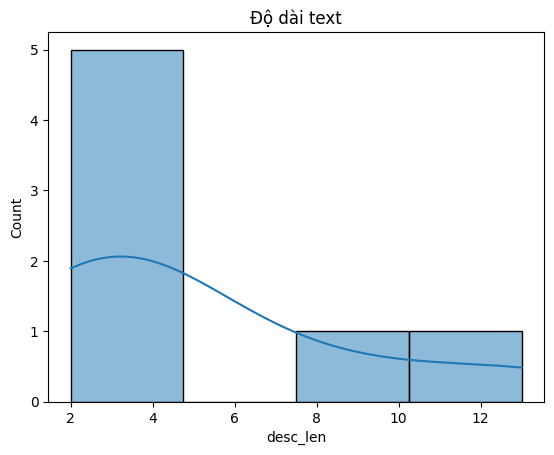


=== DATA SAU CLEAN ===
   price  area  bedrooms condition location description  desc_len
0  100.0    50         2       new       hn         dep         3
1  200.0    70         3       old      hcm         dep         4
4  150.0    80         3       new       hn          re         2
5  200.0    70         3       old      hcm         dep         3


/tmp/ipykernel_1535/1621957198.py:88: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["description"] = df["description"].fillna(method="ffill")  # text → forward fill


In [2]:
# =========================================================
# GIAI ĐOẠN 1 - KHÁM PHÁ & LÀM SẠCH DỮ LIỆU PROPTECH
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# TẠO DỮ LIỆU GIẢ LẬP
# =========================================================
df = pd.DataFrame({
    "price": [100, 200, -50, 300, None, 200],
    "area": [50, 70, 60, -10, 80, 70],
    "bedrooms": [2, 3, 0, 4, 3, 3],
    "condition": ["new", "old", "nwe", None, "new ", "old"],
    "location": ["HN", "HCM", "HN", "HN", None, "HCM"],
    "description": ["dep", None, "gan trung tam", "view dep", "re", "dep"]
})

# thêm duplicate
df = pd.concat([df, df.iloc[[0]]], ignore_index=True)


# =========================================================
# 1. KHÁM PHÁ DỮ LIỆU ĐA DẠNG
# =========================================================

# - Phân tích thống kê: mean, median, std, min, max, missing values, duplicate
print("=== THỐNG KÊ ===")
print(df.describe())                     # mean, std, min, max
print("\nMedian:\n", df.median(numeric_only=True))

print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate:", df.duplicated().sum())


# - Vẽ histogram, boxplot, violin plot cho numerical
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    # Histogram
    sns.histplot(df[col], kde=True)
    plt.title(f"Histogram - {col}")
    plt.show()

    # Boxplot
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

    # Violin
    sns.violinplot(x=df[col])
    plt.title(f"Violin - {col}")
    plt.show()


# - Phân tích phân phối categorical và text
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n{col}:\n", df[col].value_counts())

    df[col].value_counts().plot(kind='bar')
    plt.title(col)
    plt.show()

# text (description)
df["desc_len"] = df["description"].astype(str).apply(len)
sns.histplot(df["desc_len"], kde=True)
plt.title("Độ dài text")
plt.show()


# =========================================================
# 2. XỬ LÝ DỮ LIỆU BẨN
# =========================================================

# - Điền missing values tùy loại cột (mean/median/mode/forward/backward)
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())   # numerical → median

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])  # categorical → mode

df["description"] = df["description"].fillna(method="ffill")  # text → forward fill


# - Xử lý dữ liệu không hợp lệ: giá âm, số phòng = 0, typo trong categorical
df = df[df["price"] > 0]        # giá > 0
df = df[df["area"] > 0]         # diện tích > 0
df = df[df["bedrooms"] > 0]     # số phòng > 0

# sửa typo categorical
for col in cat_cols:
    df[col] = df[col].str.lower().str.strip()


# - Loại bỏ hoặc merge duplicate records
df = df.drop_duplicates()   # remove duplicate


# =========================================================
# KẾT QUẢ CUỐI
# =========================================================
print("\n=== DATA SAU CLEAN ===")
print(df)